In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

In [2]:
emails = pd.read_csv('../../data/01_raw/raw_emails.csv', low_memory=False)
emails.head()

,Co_Ref,Time_to_Renewal,crm_accreditation_completed,crm_timely_completion,crm_progress_towards_accreditation,crm_delays_in_accreditation,crm_contractor_suggested_leave,crm_contractor_engagement,crm_contractor_sentiment,crm_contractor_sentiment_score,crm_dts_or_ssip_mentioned,crm_customer_payment_intention,crm_competitors_mentioned,crm_membership_level,crm_platform_issues_raised,crm_agent_chased_contractor,crm_agent_chase_count,crm_accreditation_issues,crm_membership_overdue,crm_auto_renewal_status,crm_dissatisified_with_renewal_price,crm_customer_complained,crm_refund_mentioned,crm_negative_customer_experience,crm_dissatisfaction_with_support,crm_financial_hardship_mentioned,year
0,KG5766,pre_renewal,Not Discussed,Not Discussed,Not Discussed,Yes,No,Yes,Neutral,50,No,No,No,Not Discussed,No,Yes,1,Not Discussed,Yes,0,No,No,Yes,Yes,No,Yes,2025
1,EJ1532,14_out,Not Discussed,Not Discussed,Not Discussed,No,Not Discussed,No,Not Discussed,Not Discussed,No,Not Discussed,No,Accredited,No,Yes,1,Not Discussed,Not Discussed,0,Not Discussed,No,Yes,Yes,No,Not Discussed,2025
2,AA4063,prior_year,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Neutral,50,No,Yes,No,Accredited,No,No,0,Not Discussed,No,0,No,No,Yes,Yes,Yes,Not Discussed,2025
3,JY9888,prior_year,No,No,Not Discussed,Yes,No,Yes,Satisfied,80,Yes,Yes,No,Accredited,Yes,Yes,3,Not Discussed,Yes,0,Not Discussed,No,Yes,Yes,No,Not Discussed,2025
4,WO6689,pre_renewal,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Satisfied,80,No,Yes,No,Accredited,No,No,0,No,No,0,No,No,Yes,Yes,No,Not Discussed,2026


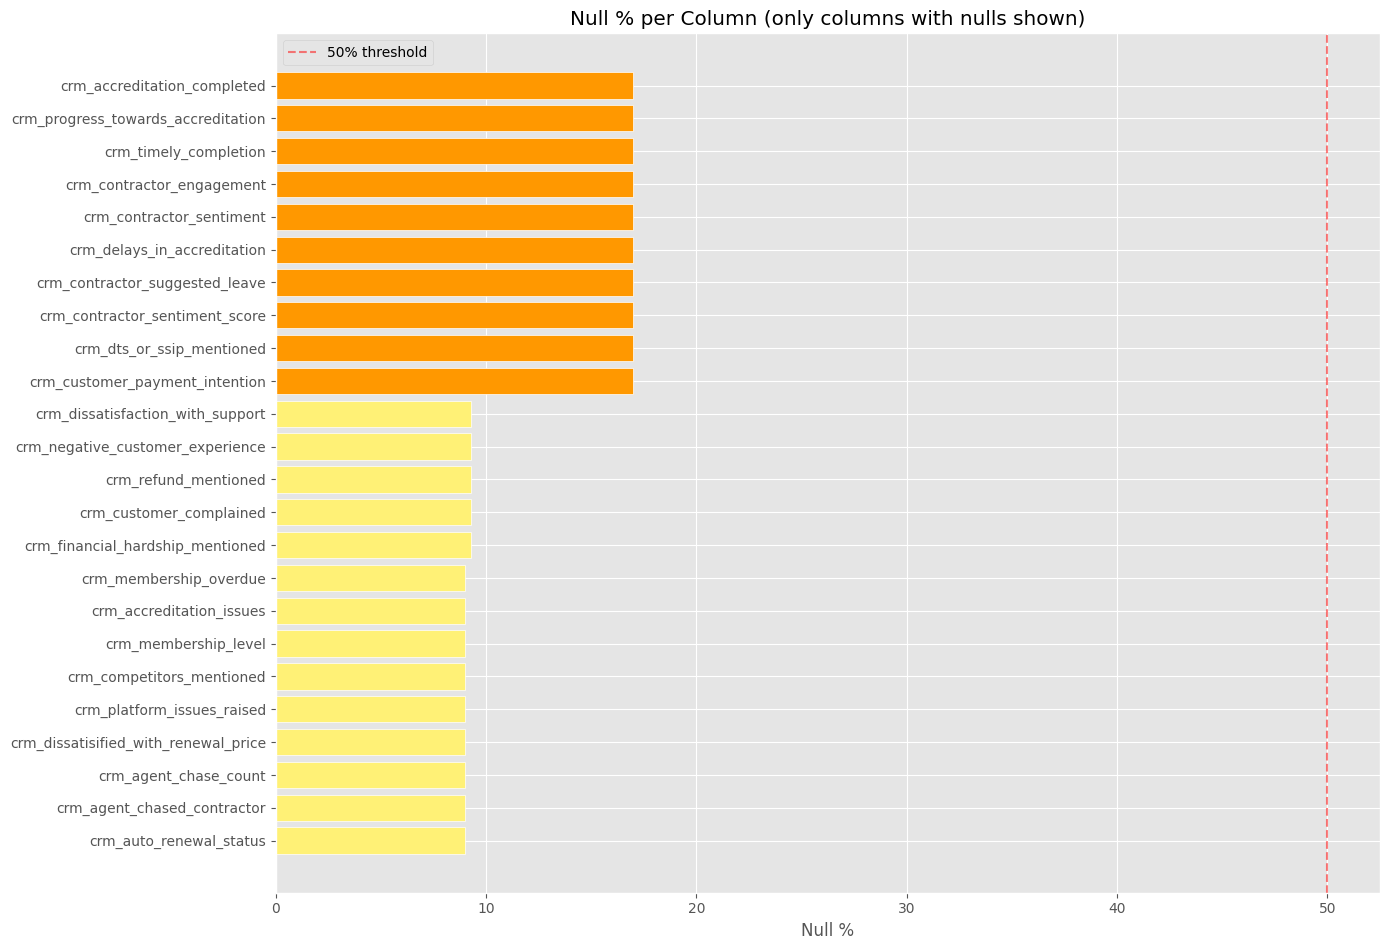


Red = >50% null (consider dropping) | Orange = >10% | Yellow = <10%


In [3]:
null_df = pd.DataFrame({
    'dtype'     : emails.dtypes,
    'null_count': emails.isnull().sum(),
    'null_pct'  : (emails.isnull().sum() / len(emails) * 100).round(1)
}).sort_values('null_pct', ascending=False)


# Visual: null heatmap
cols_with_nulls = null_df[null_df['null_pct'] > 0].index.tolist()

if cols_with_nulls:
    fig, ax = plt.subplots(figsize=(14, max(4, len(cols_with_nulls)*0.4)))
    null_vals = null_df.loc[cols_with_nulls, 'null_pct'].values
    colors = ['#E57373' if v > 50 else '#FF9800' if v > 10 else '#FFF176' for v in null_vals]
    ax.barh(cols_with_nulls[::-1], null_vals[::-1], color=colors[::-1], edgecolor='white')
    ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
    ax.set_xlabel('Null %')
    ax.set_title('Null % per Column (only columns with nulls shown)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print('\nRed = >50% null (consider dropping) | Orange = >10% | Yellow = <10%')
else:
    print('No null values in dataset.')

## Feature Distributions

In [4]:
num_cols = emails.select_dtypes(include=np.number).columns.tolist()
cat_cols = emails.select_dtypes(exclude=np.number).columns.tolist()

print(f"Numerical columns: {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")

Numerical columns: 1
Categorical columns: 26


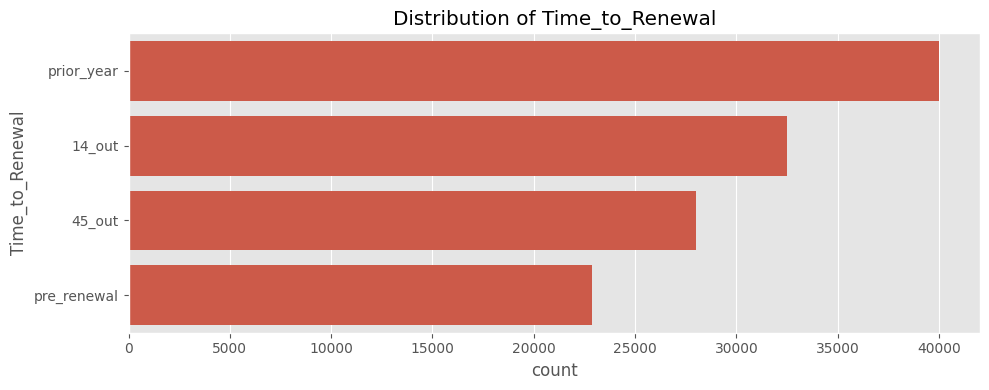

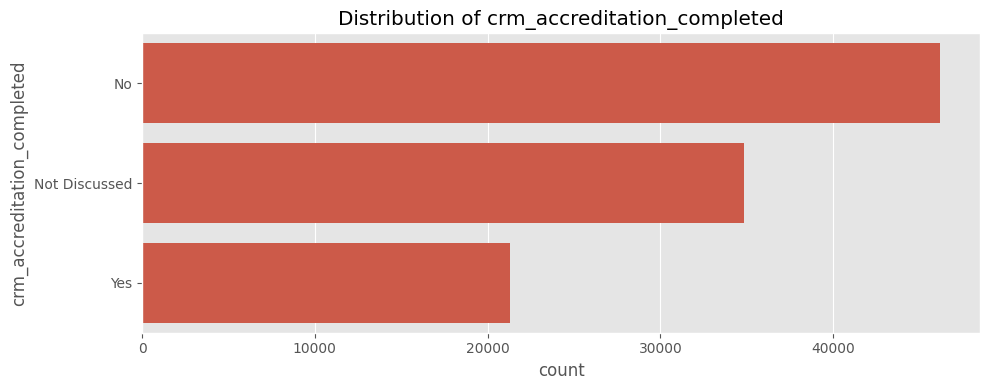

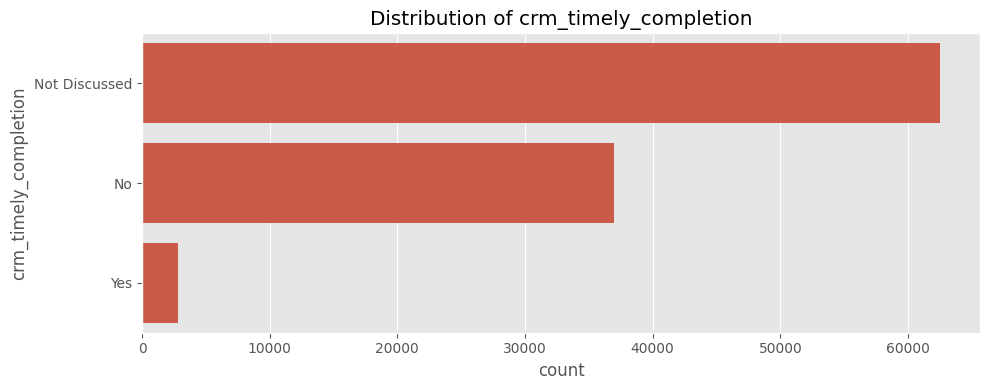

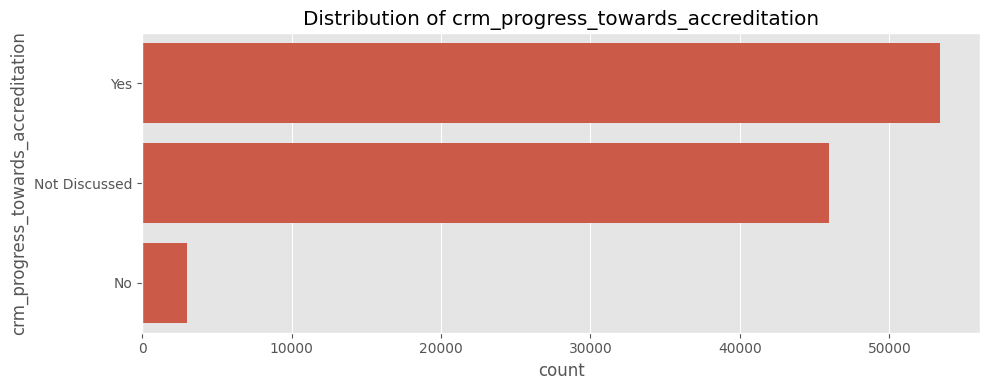

/tmp/ipykernel_23559/3830973115.py:6: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


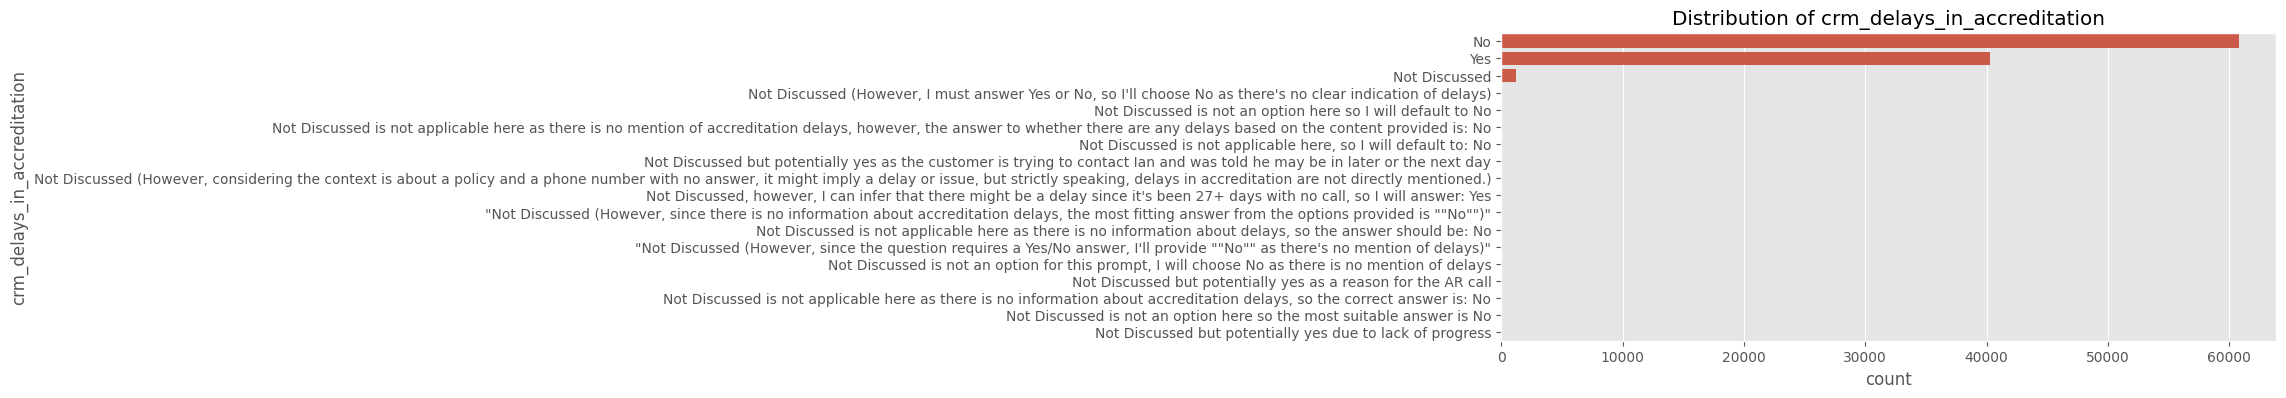

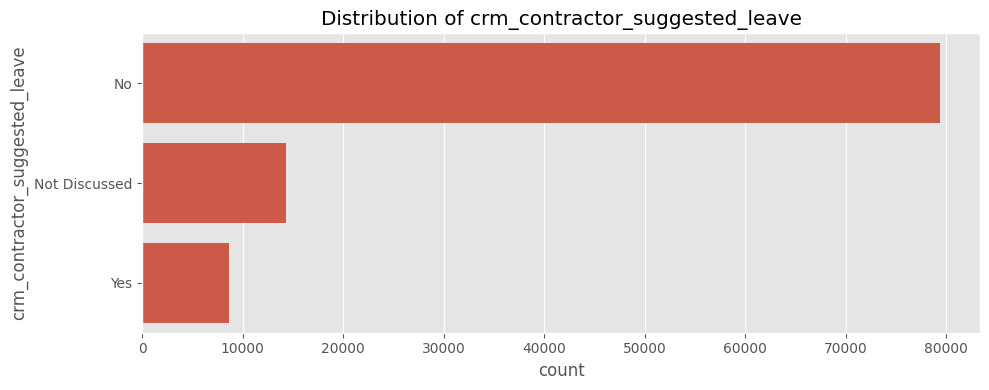

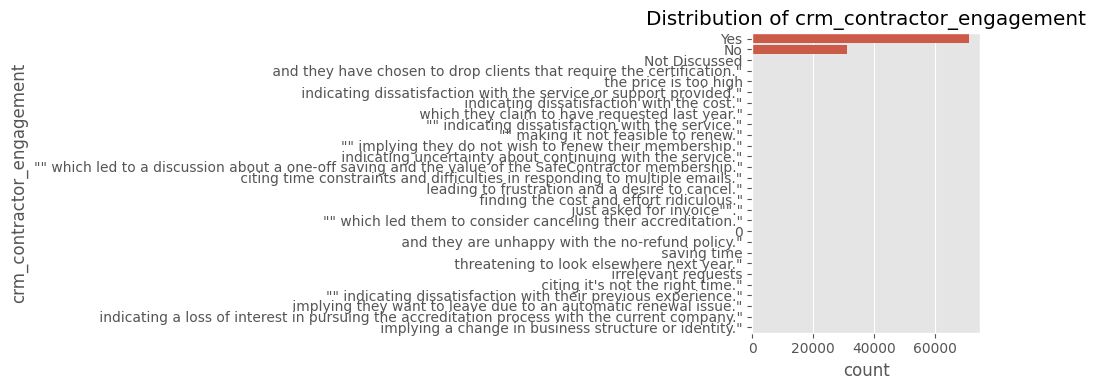

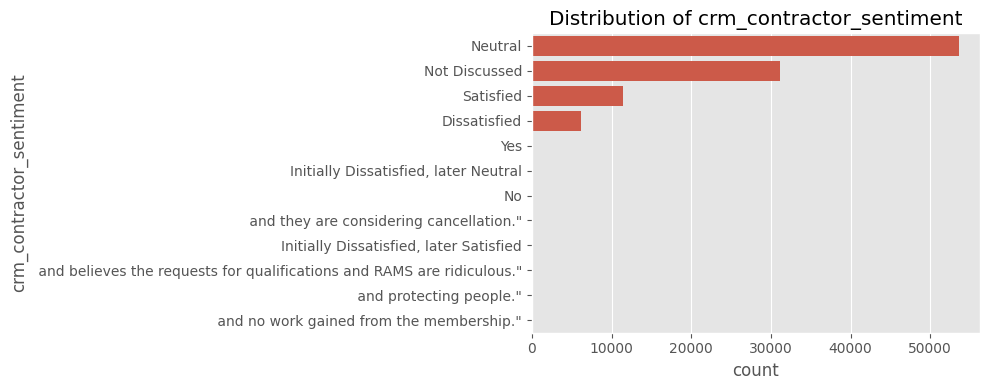

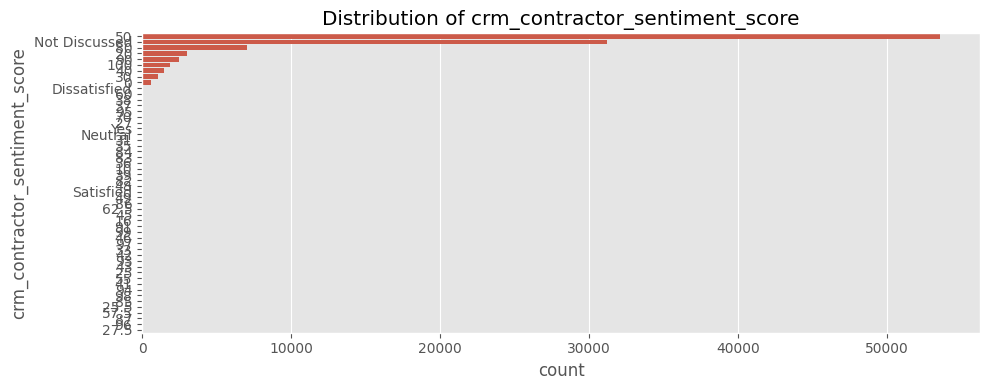

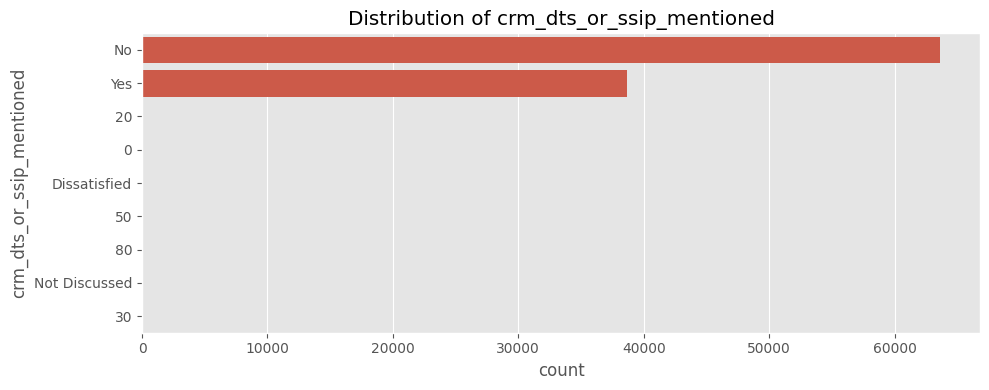

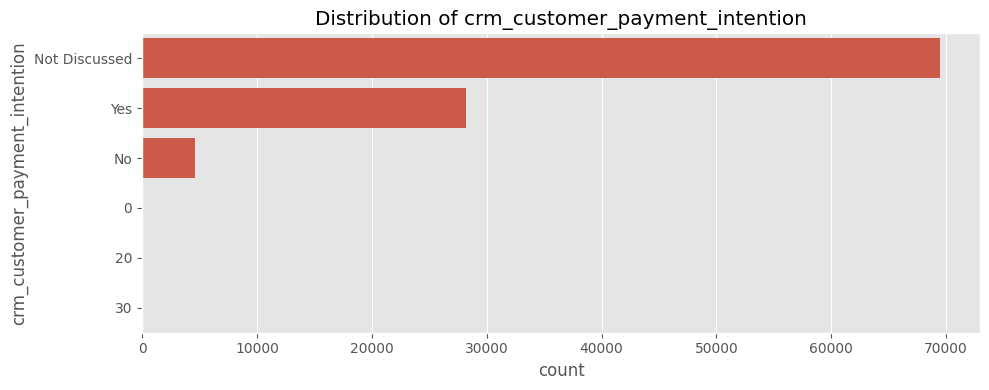

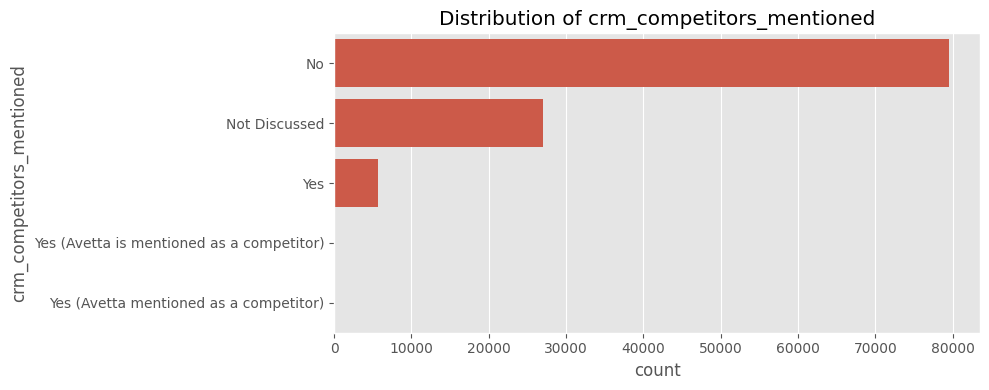

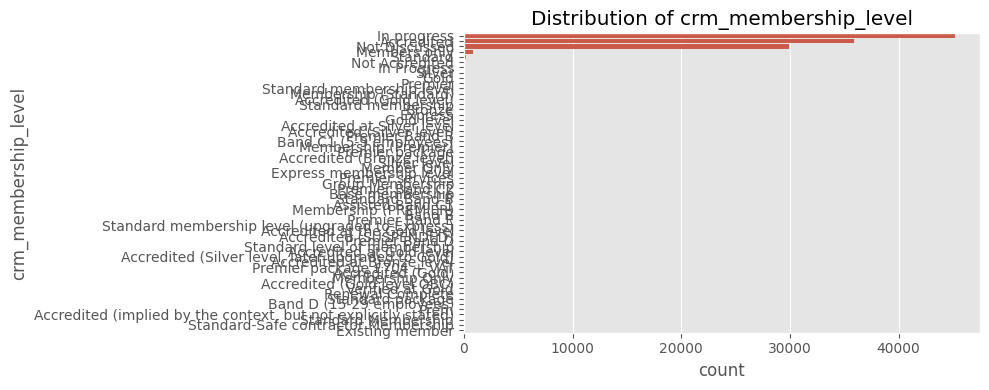

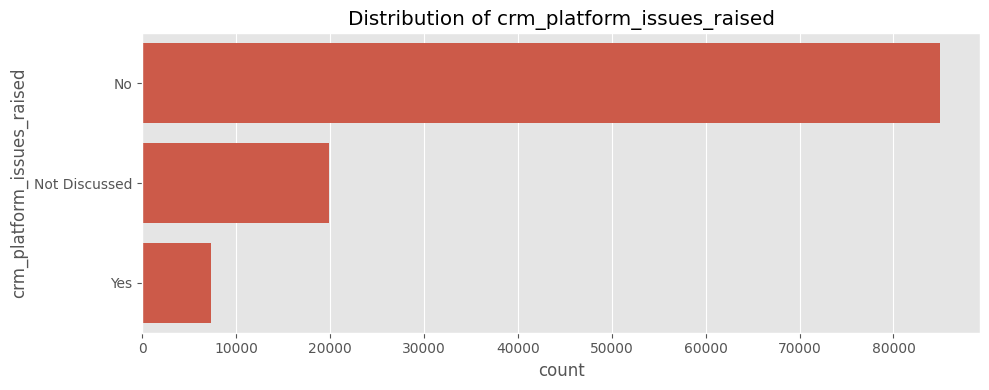

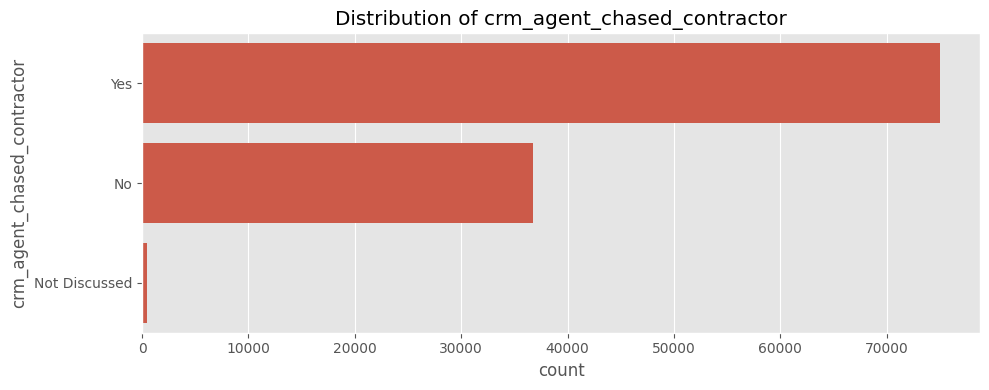

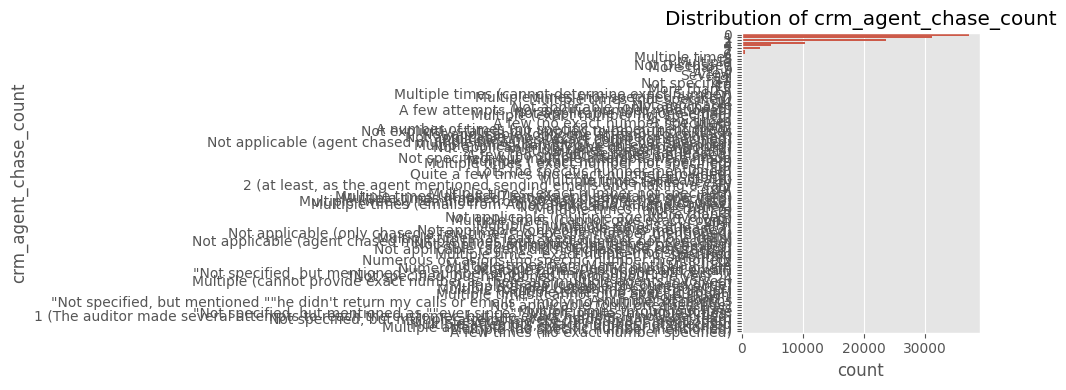

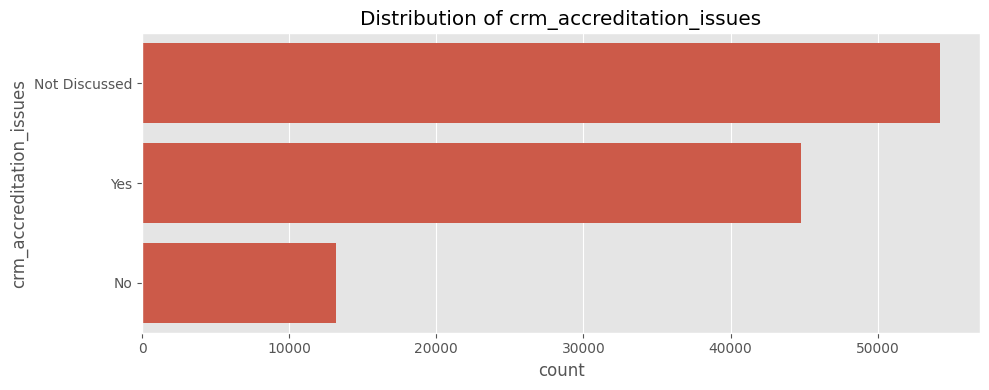

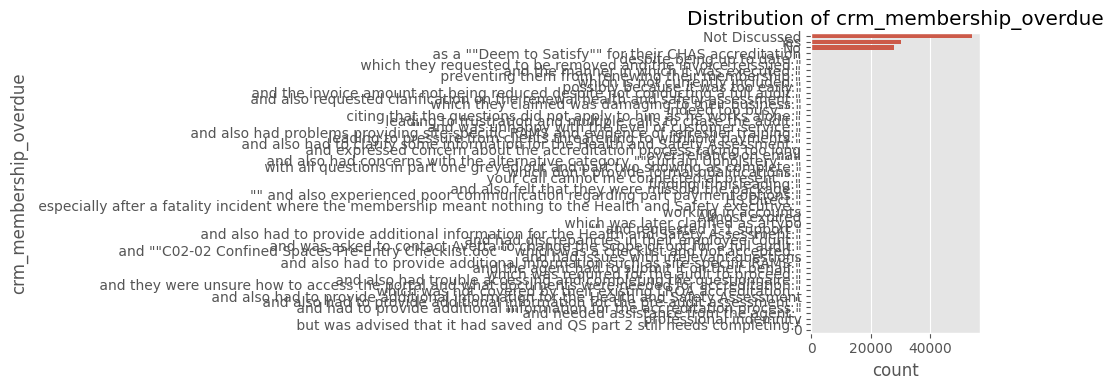

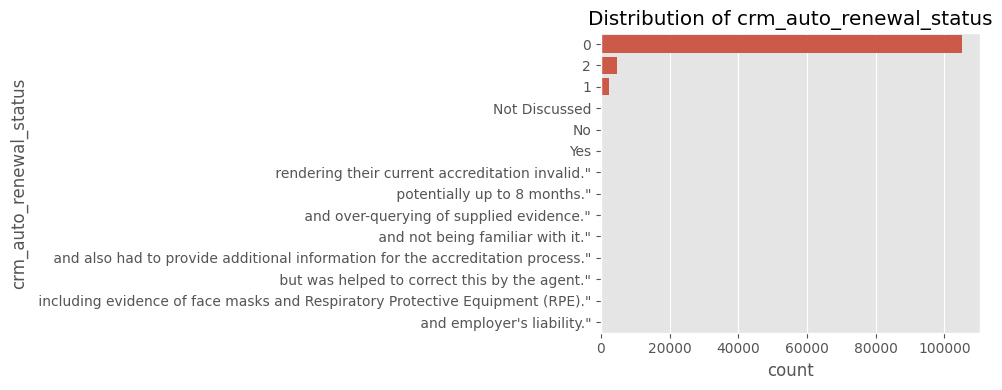

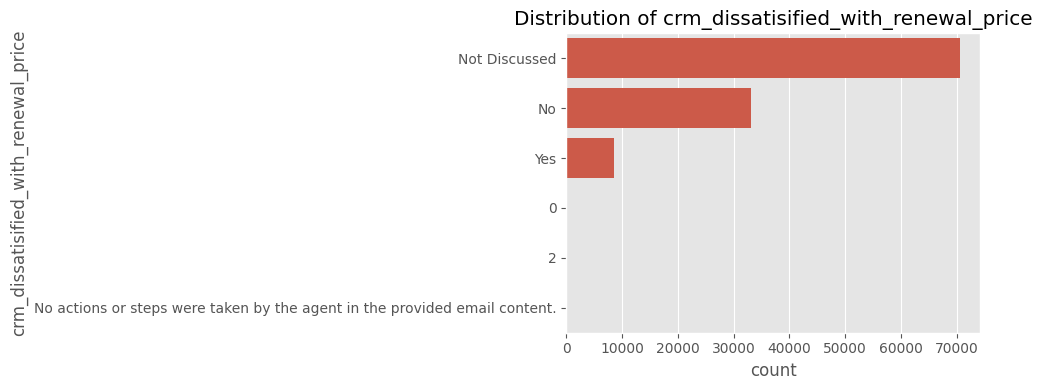

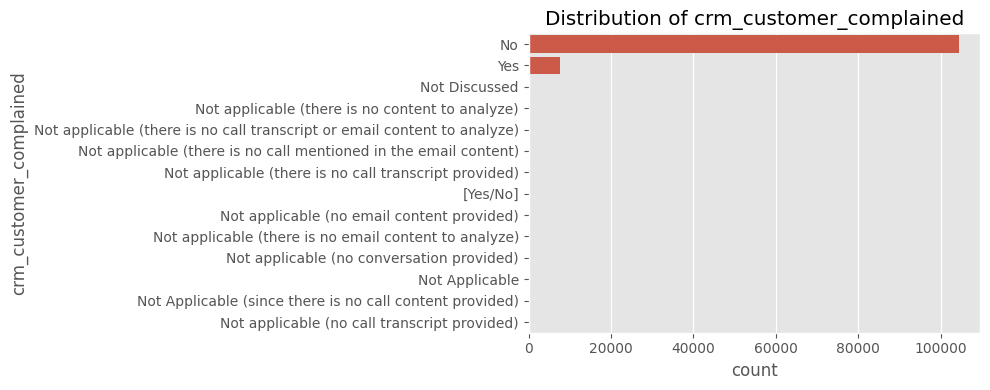

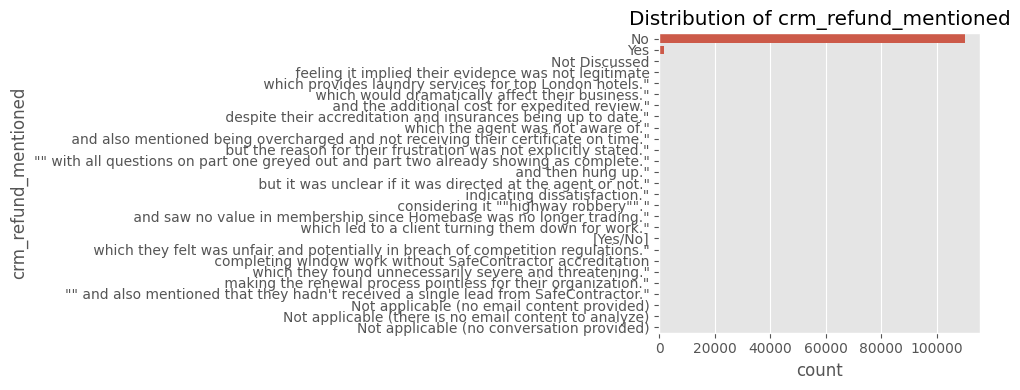

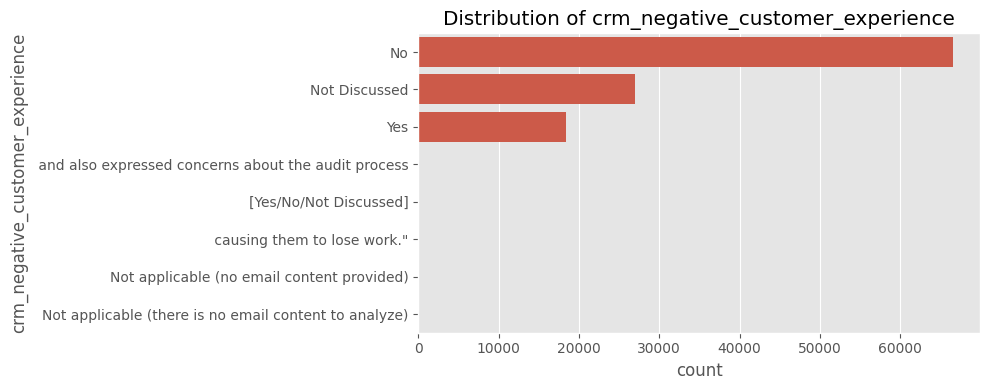

/tmp/ipykernel_23559/3830973115.py:6: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


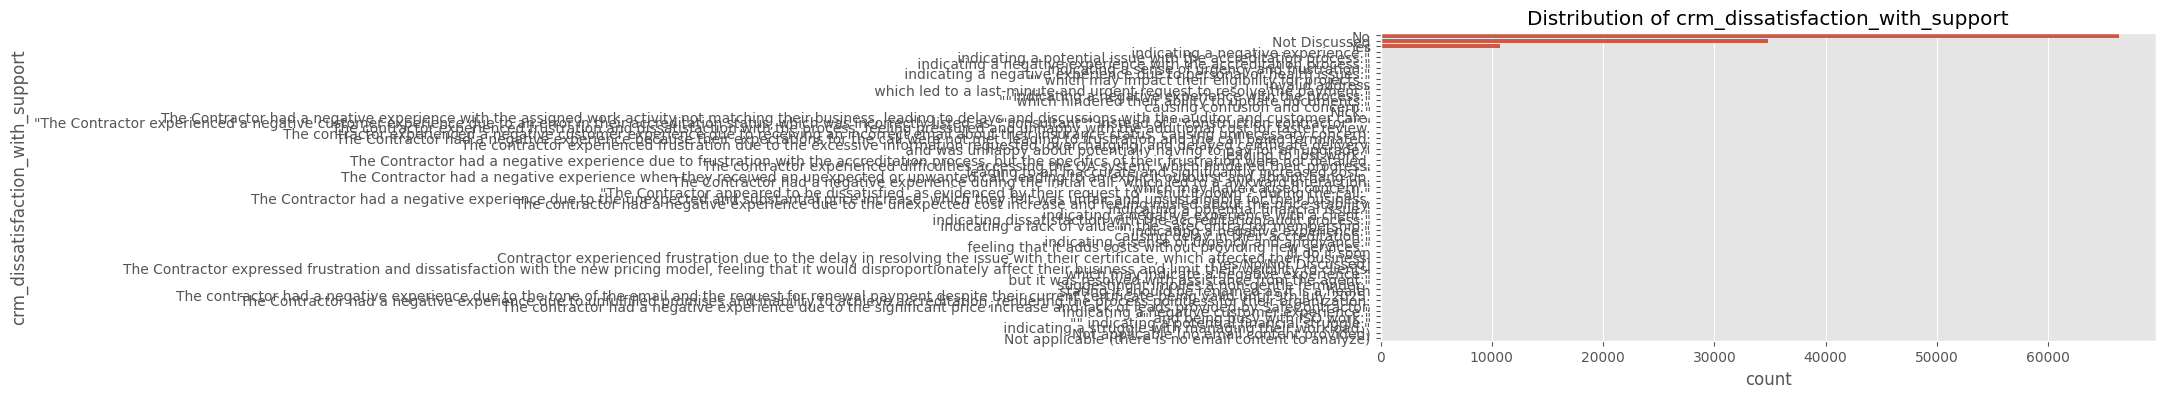

/tmp/ipykernel_23559/3830973115.py:6: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


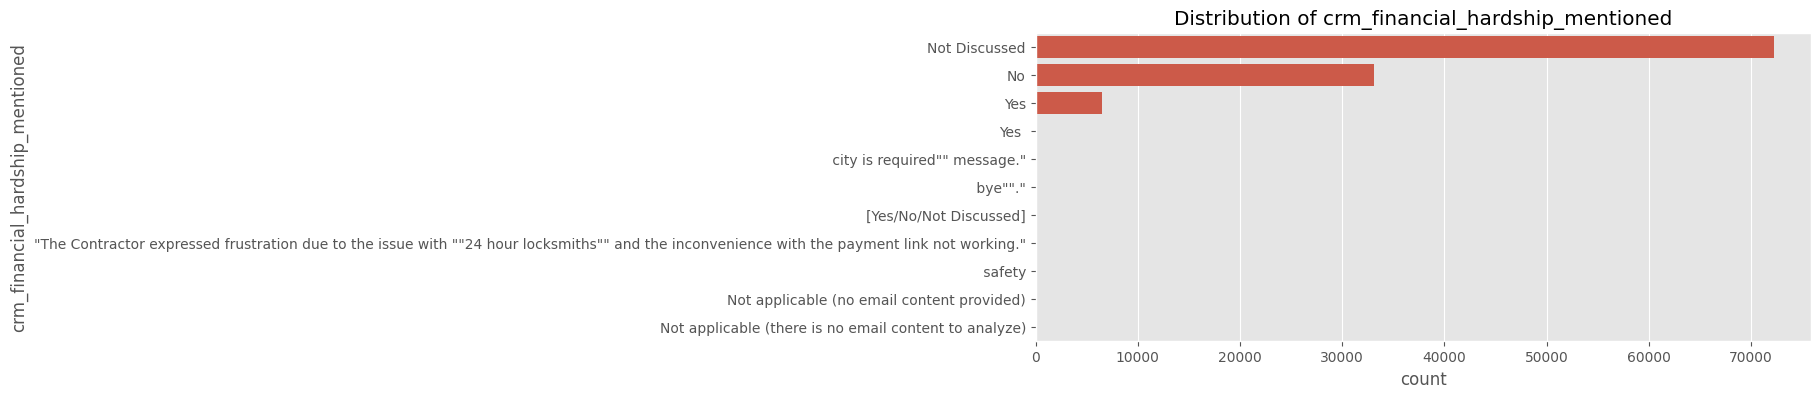

In [5]:
for col in cat_cols:
    if col not in ['Co_Ref']:
        plt.figure(figsize=(10, 4))
        sns.countplot(y=col, data=emails, order=emails[col].value_counts().index)
        plt.title(f'Distribution of {col}')
        plt.tight_layout()
        plt.show()

In [6]:
for col in num_cols:
    if col != 'year':
        plt.figure(figsize=(10, 4))
        sns.histplot(emails[col].dropna(), kde=True)
        plt.title(f'Distribution of {col}')
        plt.tight_layout()
        plt.show()